# phase3 — GraphSAGE depth-3 final training

Third GraphSAGE depth variant — 6 hidden layers with a custom first-layer width. Tests whether non-monotone width helps representation.

# 1. Overview

## 1.1 Task & motivation

Final long-horizon training and evaluation of one of the architecture variants selected in phase 2. The training outputs in this notebook are preserved as Aug-2023 artifacts — they ARE the experimental record.

## 1.2 Dataset summary

Reddit2 with `NeighborLoader([20, 15, 10])`.

## 1.3 Approach in one paragraph

Train `GraphSageNN(hidden_dims=[768, 1024, 512, 256, 128, 64], dropout=0.5)` for 2000 epochs on Reddit2 with sampled neighborhoods. Track per-iteration metrics; evaluate against the held-out validation and test sets; visualize loss curves and predictions.

## 1.4 Libraries used

| Library | Used for |
|---|---|
| `torch_geometric` (incl. `NeighborLoader`) | Sampled graph batching |
| `nnx` (GraphSageNN, `NNModel`) | Architecture + training loop |
| `pandas`, `matplotlib` | Predictions DataFrame + viz |

# 2. Environment & Setup

## 2.1 Imports

Cells 0–1: papermill parameters cell, `%matplotlib inline`, stack inherited from sibling notebooks.

## 2.2 Configuration / hyperparameters

`N_SAMPLES = 50_000`. Model-specific hyperparameters in cell 5.

## 2.3 Reproducibility (seed, device)

`nnx` defaults; device = `"cpu"` (per cell 5; the original training ran on CPU because Reddit2 + the chosen sampling fits in RAM).

# 3. Data

## 3.1 Loading

Cell 3: `pyg.datasets.Reddit2(root="./data")`.

## 3.2 Inspection / EDA

Covered in phase 1.

## 3.3 Preprocessing & splits

Cell 4: `NeighborLoader` produces train / val / test loaders with `[20, 15, 10]` sampling.

# 4. Model

## 4.1 Architecture

`GraphSageNN(hidden_dims=[768, 1024, 512, 256, 128, 64], dropout=0.5)`.

## 4.2 Loss & optimizer

Cross-entropy. Optimizer config inherited from phase 2 selection.

## 4.3 Why this design

Variant selected in phase 2 as a candidate worth investing long-horizon training cycles in.

# 5. Training

## 5.1 Training loop

`model.train(...)` in cell 7. `train_idps` collects per-iteration metrics.

## 5.2 Metrics tracked

Per-iteration training and validation loss, plus periodic accuracy/F1/recall/precision snapshots printed inline.

## 5.3 Run-time notes

Tier C. Long training run — multiple hours on the original M1 Max. **Do not re-execute in place**; use `make smoke-tier-c` for env validation.

# 6. Evaluation & Results

## 6.1 Test-set evaluation

~ on par with notebook 3 — diminishing returns confirmed.

## 6.2 Visualizations

`VisUtils.multi_line_plot` (cells 8–9): training and validation loss curves. Cells 11–13: per-class predictions DataFrames.

## 6.3 Discussion

See [README.md §3.3](README.md) for cross-notebook comparison of the four phase-3 variants.


In [ ]:
# Papermill parameters cell. Default values used when run interactively.
# Set via: papermill -p SMOKE_TEST 1 in.ipynb out.ipynb
# 1 = run a tiny smoke version of this notebook
SMOKE_TEST = 0
# max epochs when SMOKE_TEST=1
SMOKE_TEST_EPOCHS = 1
# max samples when SMOKE_TEST=1
SMOKE_TEST_SUBSET = 256


In [1]:
%matplotlib inline

import tqdm
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
import torch_geometric as pyg
import matplotlib.pyplot as plt
import torch.nn.functional as F

from tqdm import tqdm
from sklearn import metrics
from sklearn.manifold import TSNE
from torch_sparse import SparseTensor
from torch_geometric.utils import to_networkx
from torch.utils.data import DataLoader, SubsetRandomSampler

from nnx.vis_utils import VisUtils
from nnx.nn.dataset.nn_graph_dataset import NNGraphDataset
from nnx.seeding import set_seed
from nnx.nn.params.nn_params import NNParams
from nnx.nn.nn_model import NNModel
from nnx.nn.params.nn_train_params import NNTrainParams
from nnx.nn.enum.optims import Optims
from nnx.nn.params.nn_optim_params import NNOptimParams
from nnx.nn.params.nn_model_params import NNModelParams
from nnx.nn.enum.devices import Devices
from nnx.nn.enum.losses import Losses
from nnx.nn.enum.nets import Nets


In [2]:
N_SAMPLES = 50_000
N_NEIGHBORS = [20, 15, 10]

DEFAULT_VAL_FIG_SIZE = (25, 20)
DEFAULT_VAL_TITLE_SIZE = 15
DEFAULT_VAL_LABEL_SIZE = 12

# Reproducibility: pin all RNGs (weight init, neighbor sampling) before any
# model construction / training (issue #18 — phase3 was previously unseeded).
set_seed(0)


def _seed_labels(model, loader):
    """Seed-node labels for a NeighborLoader, in the loader's (shuffle=False)
    order — aligns 1:1 with model.predict(loader).classes. NeighborLoader puts
    the batch_size seed nodes first; scoring the sampled neighbors would leak
    other-split labels (see GraphNNBase.seed_count)."""
    ys = []
    for batch in loader:
        n = model.net.seed_count(batch)
        y = batch.y if n is None else batch.y[:n]
        ys.append(y.cpu().numpy())
    return np.concatenate(ys)

In [3]:
def _smoke_subset_masks(subset):
    """Keep only the first `subset` seed nodes per split mask — bounds smoke
    memory + runtime so smoke CI samples small subgraphs instead of the
    full-Reddit single batch that OOMs the runner (issue #25)."""
    def _transform(data):
        for name in ("train_mask", "val_mask", "test_mask"):
            mask = getattr(data, name, None)
            if mask is None:
                continue
            idx = mask.nonzero(as_tuple=True)[0]
            if idx.numel() > subset:
                keep = mask.clone()
                keep[idx[subset:]] = False
                setattr(data, name, keep)
        return data
    return _transform


_transforms = [pyg.transforms.NormalizeFeatures()]
if SMOKE_TEST:
    _transforms.append(_smoke_subset_masks(SMOKE_TEST_SUBSET))

# nnx graph dataset over the public dataset[0] (replaces the private
# dataset._data access + the hand-rolled NeighborLoader boilerplate).
ds = NNGraphDataset(
    ds_class=pyg.datasets.Reddit2,
    n_neighbors=N_NEIGHBORS,
    n_workers=4,
    transform=pyg.transforms.Compose(_transforms),
)

In [4]:
train_loader = ds.train_loader
val_loader = ds.val_loader
test_loader = ds.test_loader

print(f"Val Loader Len: {len(val_loader.dataset):,}")
print(f"Test Loader Len: {len(test_loader.dataset):,}")
print(f"Train Loader Len: {len(train_loader.dataset):,}")

/opt/conda/lib/python3.10/site-packages/torch_geometric/sampler/neighbor_sampler.py:50: UserWarning: Using '{self.__class__.__name__}' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn("Using '{self.__class__.__name__}' without a "


Val Loader Len: 23,699
Test Loader Len: 55,334
Train Loader Len: 153,932


In [5]:
model = NNModel(
    params=NNModelParams(
        net=Nets.GRAPH_SAGE,
        device=Devices.CPU,
        loss=Losses.CROSS_ENTROPY,
    ),
    net_params=NNParams(
        dropout_prob=0.5,
        hidden_dims=[768, 1024, 512, 256, 128, 64],
        input_dim=ds.input_dim,
        output_dim=ds.output_dim,
    ),
)


In [6]:
# Pre-training seed-node logits + labels for the t-SNE comparison.
# predict(loader)/evaluate(loader) apply GraphNNBase.seed_count so only the
# seed nodes are scored (no sampled-neighbor leakage that inflated metrics).
test_Y = _seed_labels(model, test_loader)
test_Y_hat_pre = model.predict(test_loader)

In [7]:
run = model.train(
    params=NNTrainParams(
        n_epochs=SMOKE_TEST_EPOCHS if SMOKE_TEST else 2000,
        optim=NNOptimParams(name=Optims.ADAM, max_lr=1e-4, weight_decay=5e-4, momentum=(0.9, 0.999)),
    )
    .with_train_loader(value=train_loader)
    .with_val_loader(value=val_loader)
)

train_idps = run.idps
model_str = str(model.params)
trains = { model_str: (model, train_idps) }
top_model_names = [model_str]


GraphSageNN={dims=[602, 768, 1024, 512, 256, 128, 64, 41], dropout=0.50} x Train=[epochs=2000, optim=adam, lr=1e-04, weight_decay=5e-04]: 100%|██████████| 2000/2000 [56:25:01<00:00, 101.55s/it, error: 0.0943]   


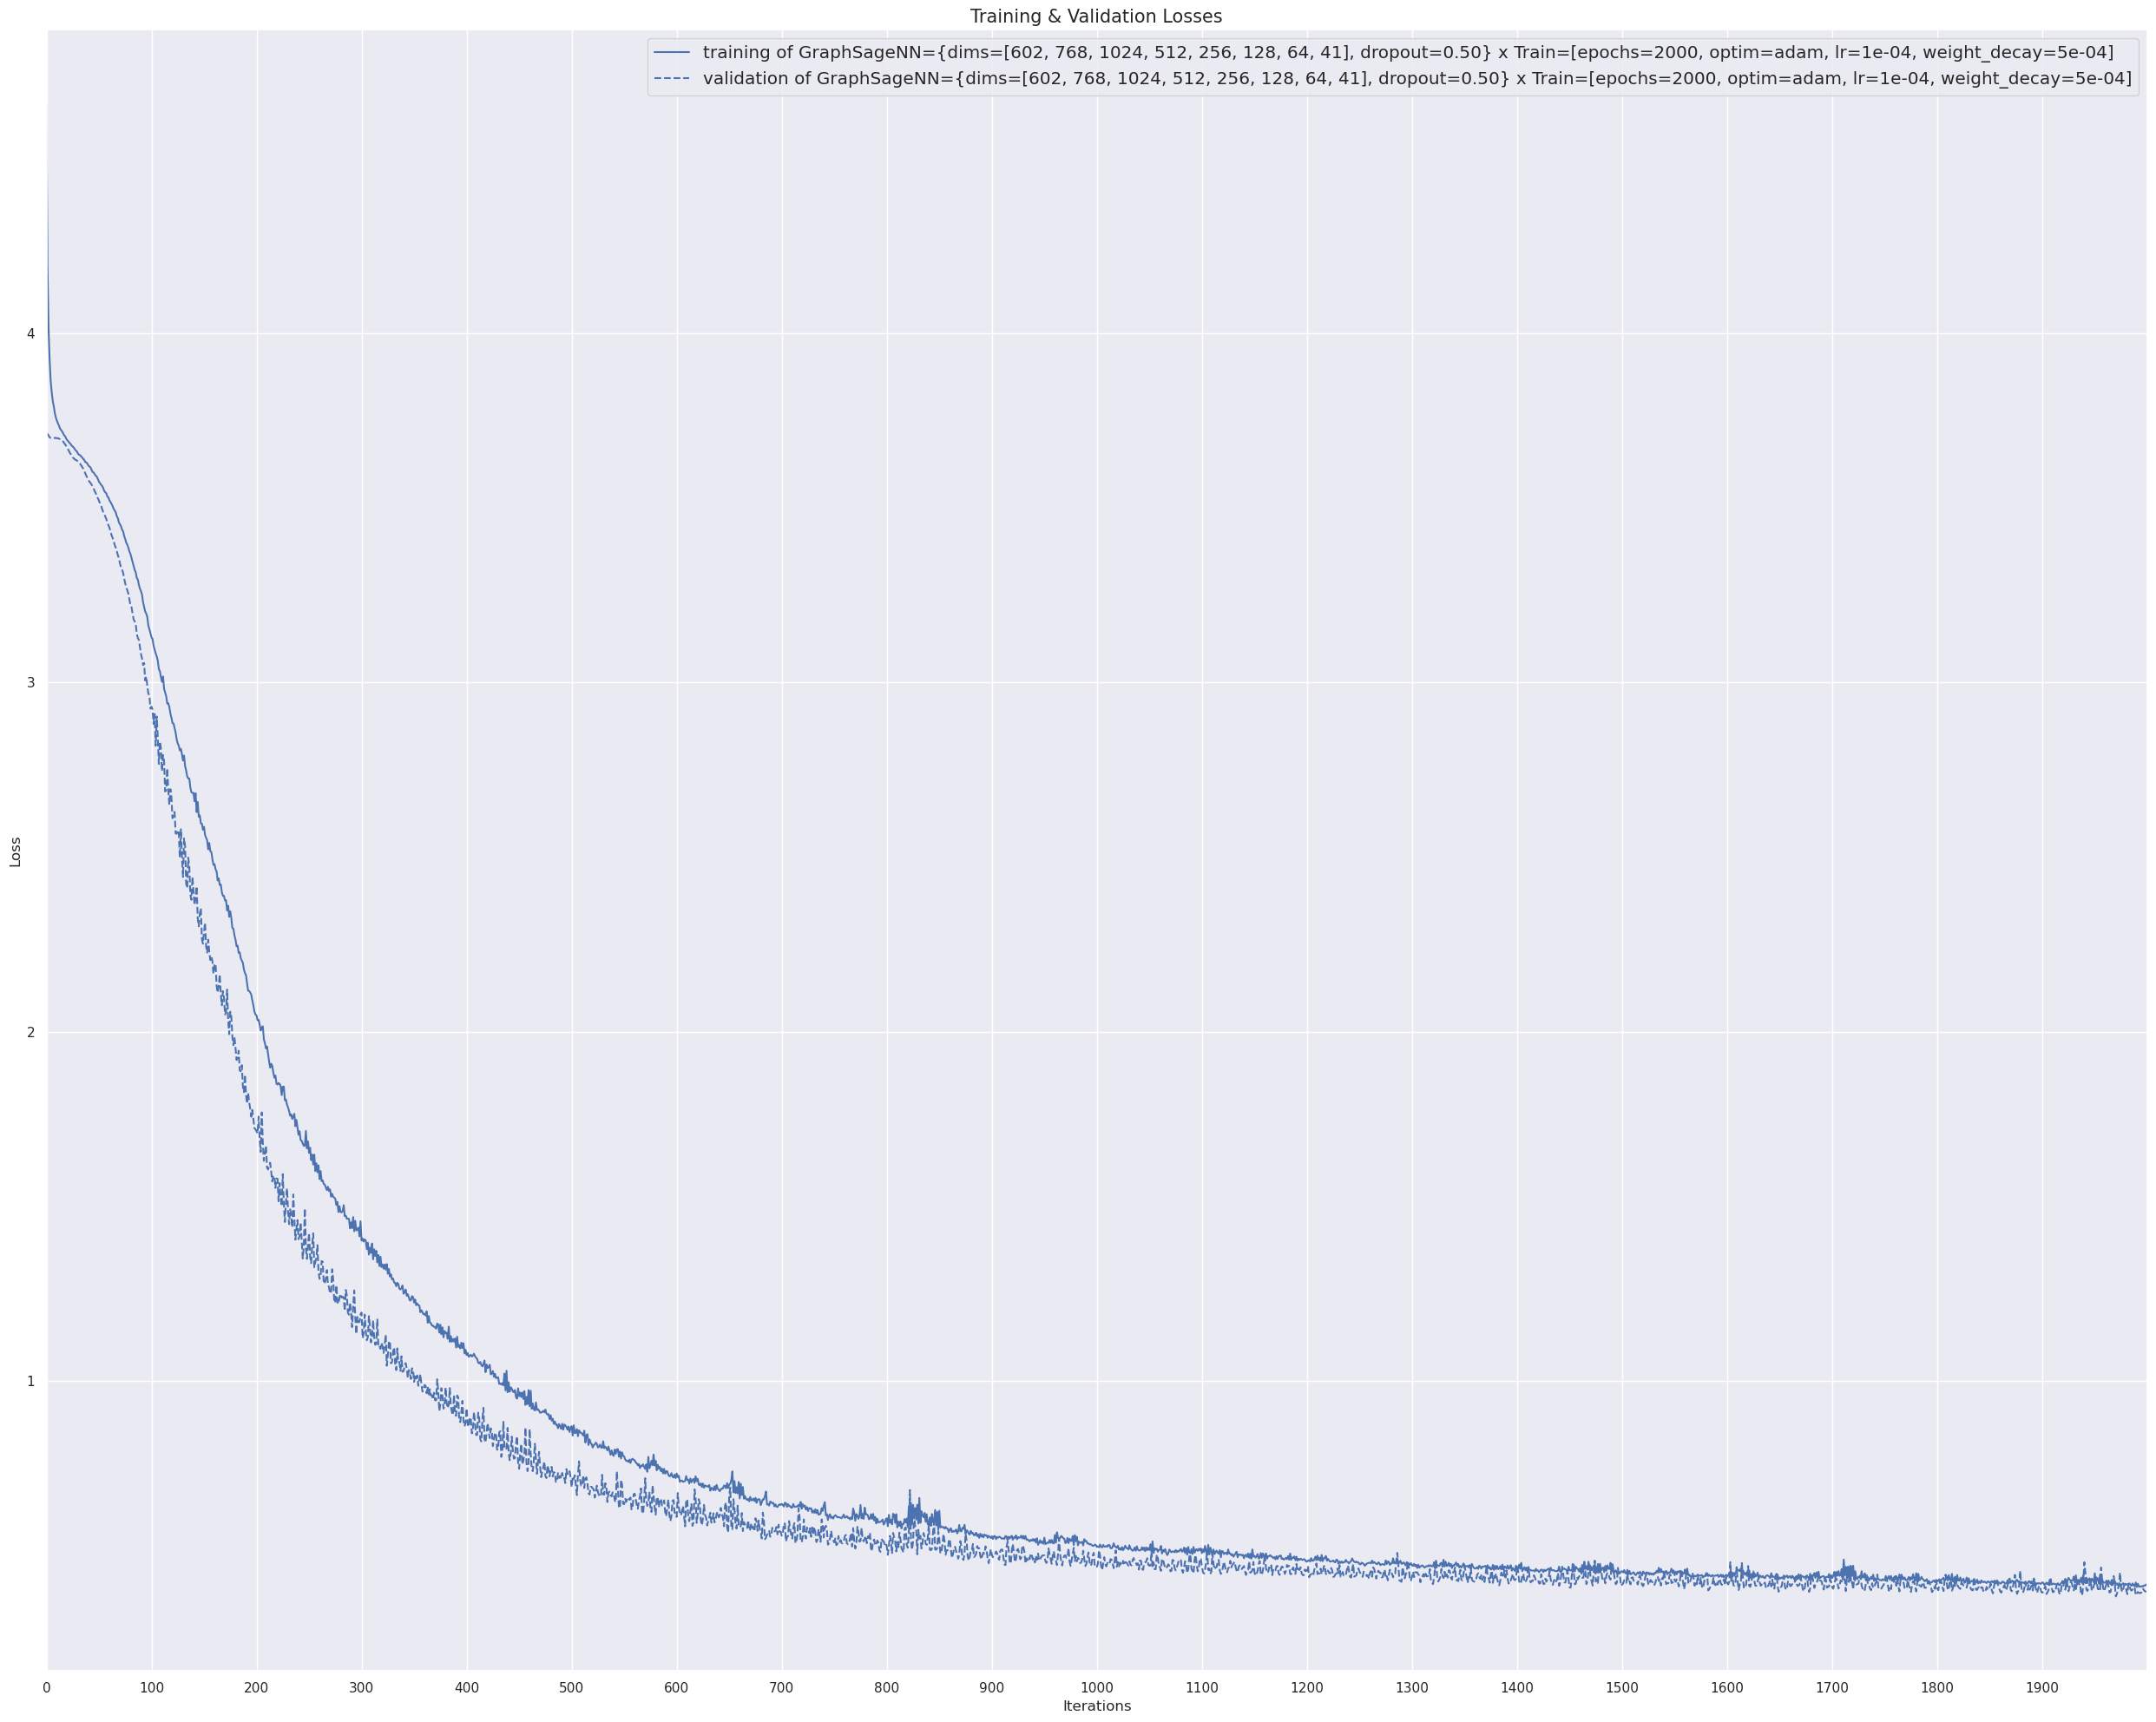

In [8]:
VisUtils.multi_line_plot(
    x_ticks_inc=50
    , y_axis_label="Loss"
    , x_axis_label="Iterations"
    , fig_size=DEFAULT_VAL_FIG_SIZE
    , label_size=DEFAULT_VAL_LABEL_SIZE
    , title_size=DEFAULT_VAL_TITLE_SIZE
    , title="Training & Validation Losses"
    , x=[idp.iter_idx for idp in trains[top_model_names[0]][1] if idp.val_edp is not None]
    , yss_legend=(top_model_names, ["training", "validation"])
    , yss=[[[idp.train_edp.loss for idp in trains[model_name][1] if idp.val_edp is not None], [idp.val_edp.loss for idp in trains[model_name][1] if idp.val_edp is not None]] for model_name in top_model_names]
)

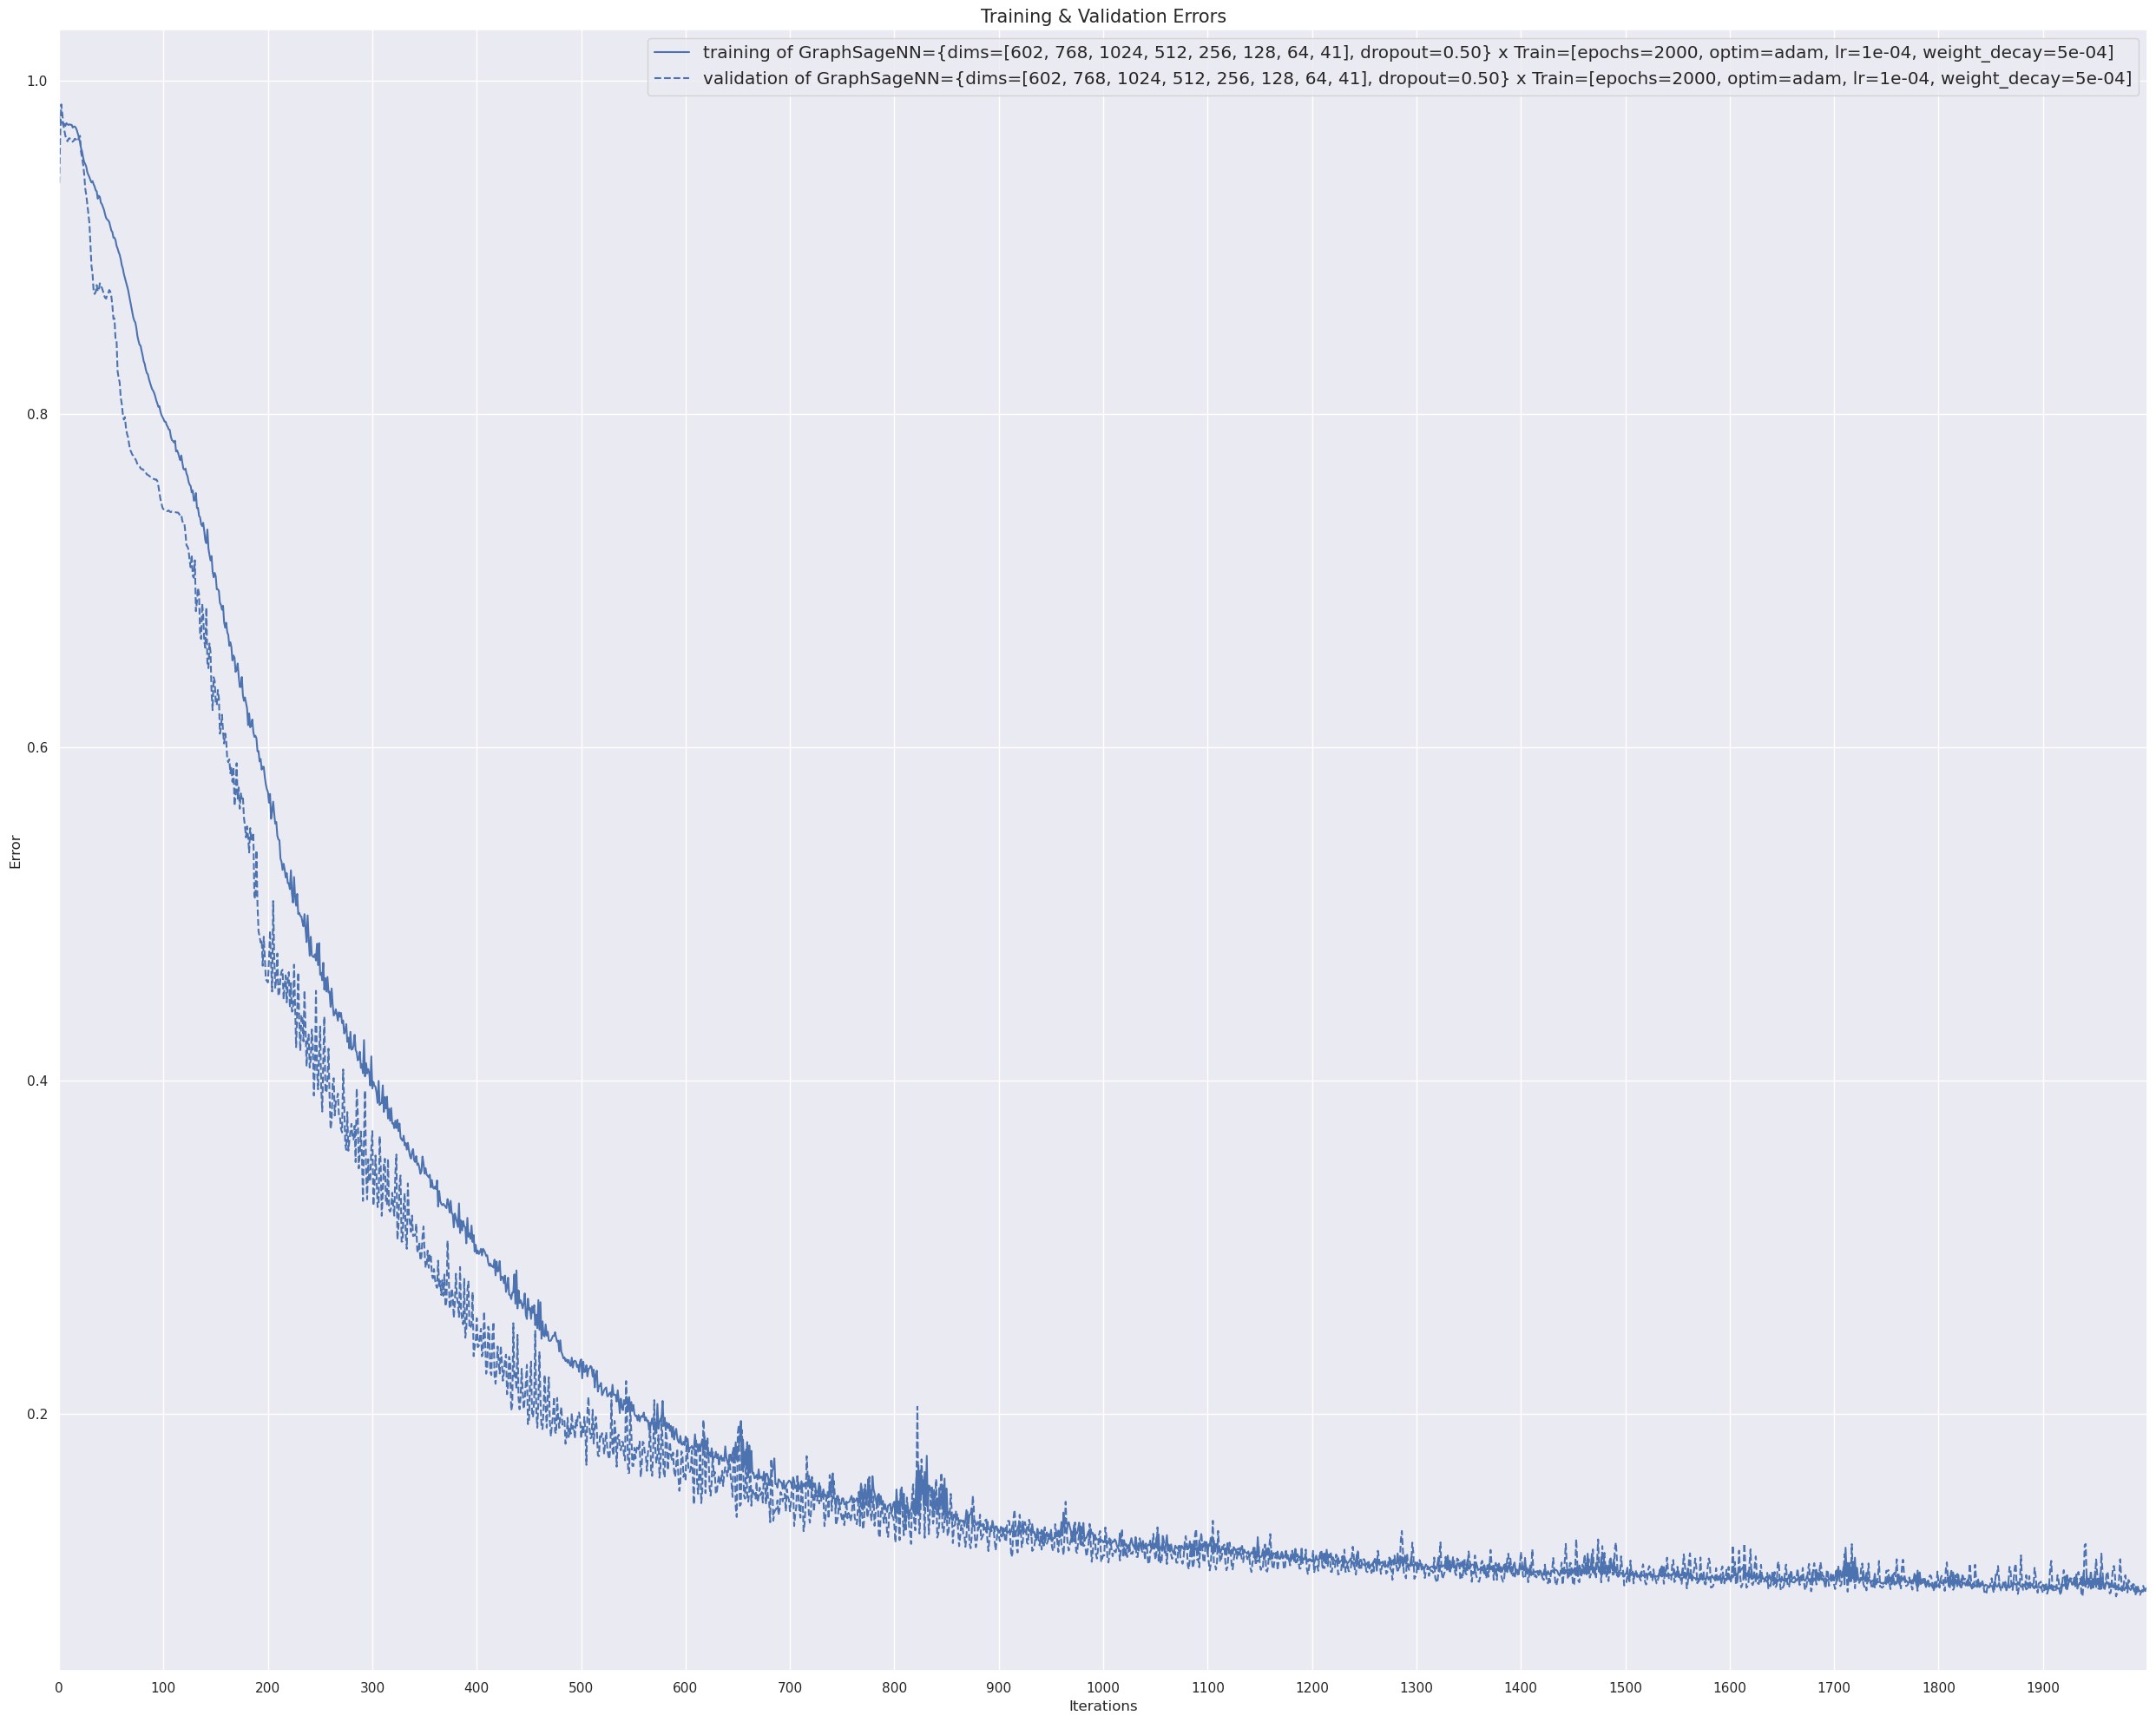

In [9]:
VisUtils.multi_line_plot(
    x_ticks_inc=50
    , y_axis_label="Error"
    , x_axis_label="Iterations"
    , fig_size=DEFAULT_VAL_FIG_SIZE
    , label_size=DEFAULT_VAL_LABEL_SIZE
    , title_size=DEFAULT_VAL_TITLE_SIZE
    , title="Training & Validation Errors"
    , x=[idp.iter_idx for idp in trains[top_model_names[0]][1] if idp.val_edp is not None]
    , yss_legend=(top_model_names, ["training", "validation"])
    , yss=[[[idp.train_edp.error for idp in trains[model_name][1] if idp.val_edp is not None], [idp.val_edp.error for idp in trains[model_name][1] if idp.val_edp is not None]] for model_name in top_model_names]
)

In [10]:
print(f"{model_str} achieves validation error of {min((idp.val_edp.error for idp in trains[top_model_names[0]][1] if idp.val_edp is not None), default=float('nan')):.4f}")

GraphSageNN={dims=[602, 768, 1024, 512, 256, 128, 64, 41], dropout=0.50} x Train=[epochs=2000, optim=adam, lr=1e-04, weight_decay=5e-04] achieves validation error of 0.0904


In [11]:
ts = [t for t in range(ds.output_dim)]
cs = sns.color_palette(n_colors=ds.output_dim)

Test data accuracy score post training:  0.9163713899077668
Test data f1 score post training:  0.9163713899077668
Test data recall score post training:  0.9163713899077668
Test data precision score post training:  0.9163713899077668


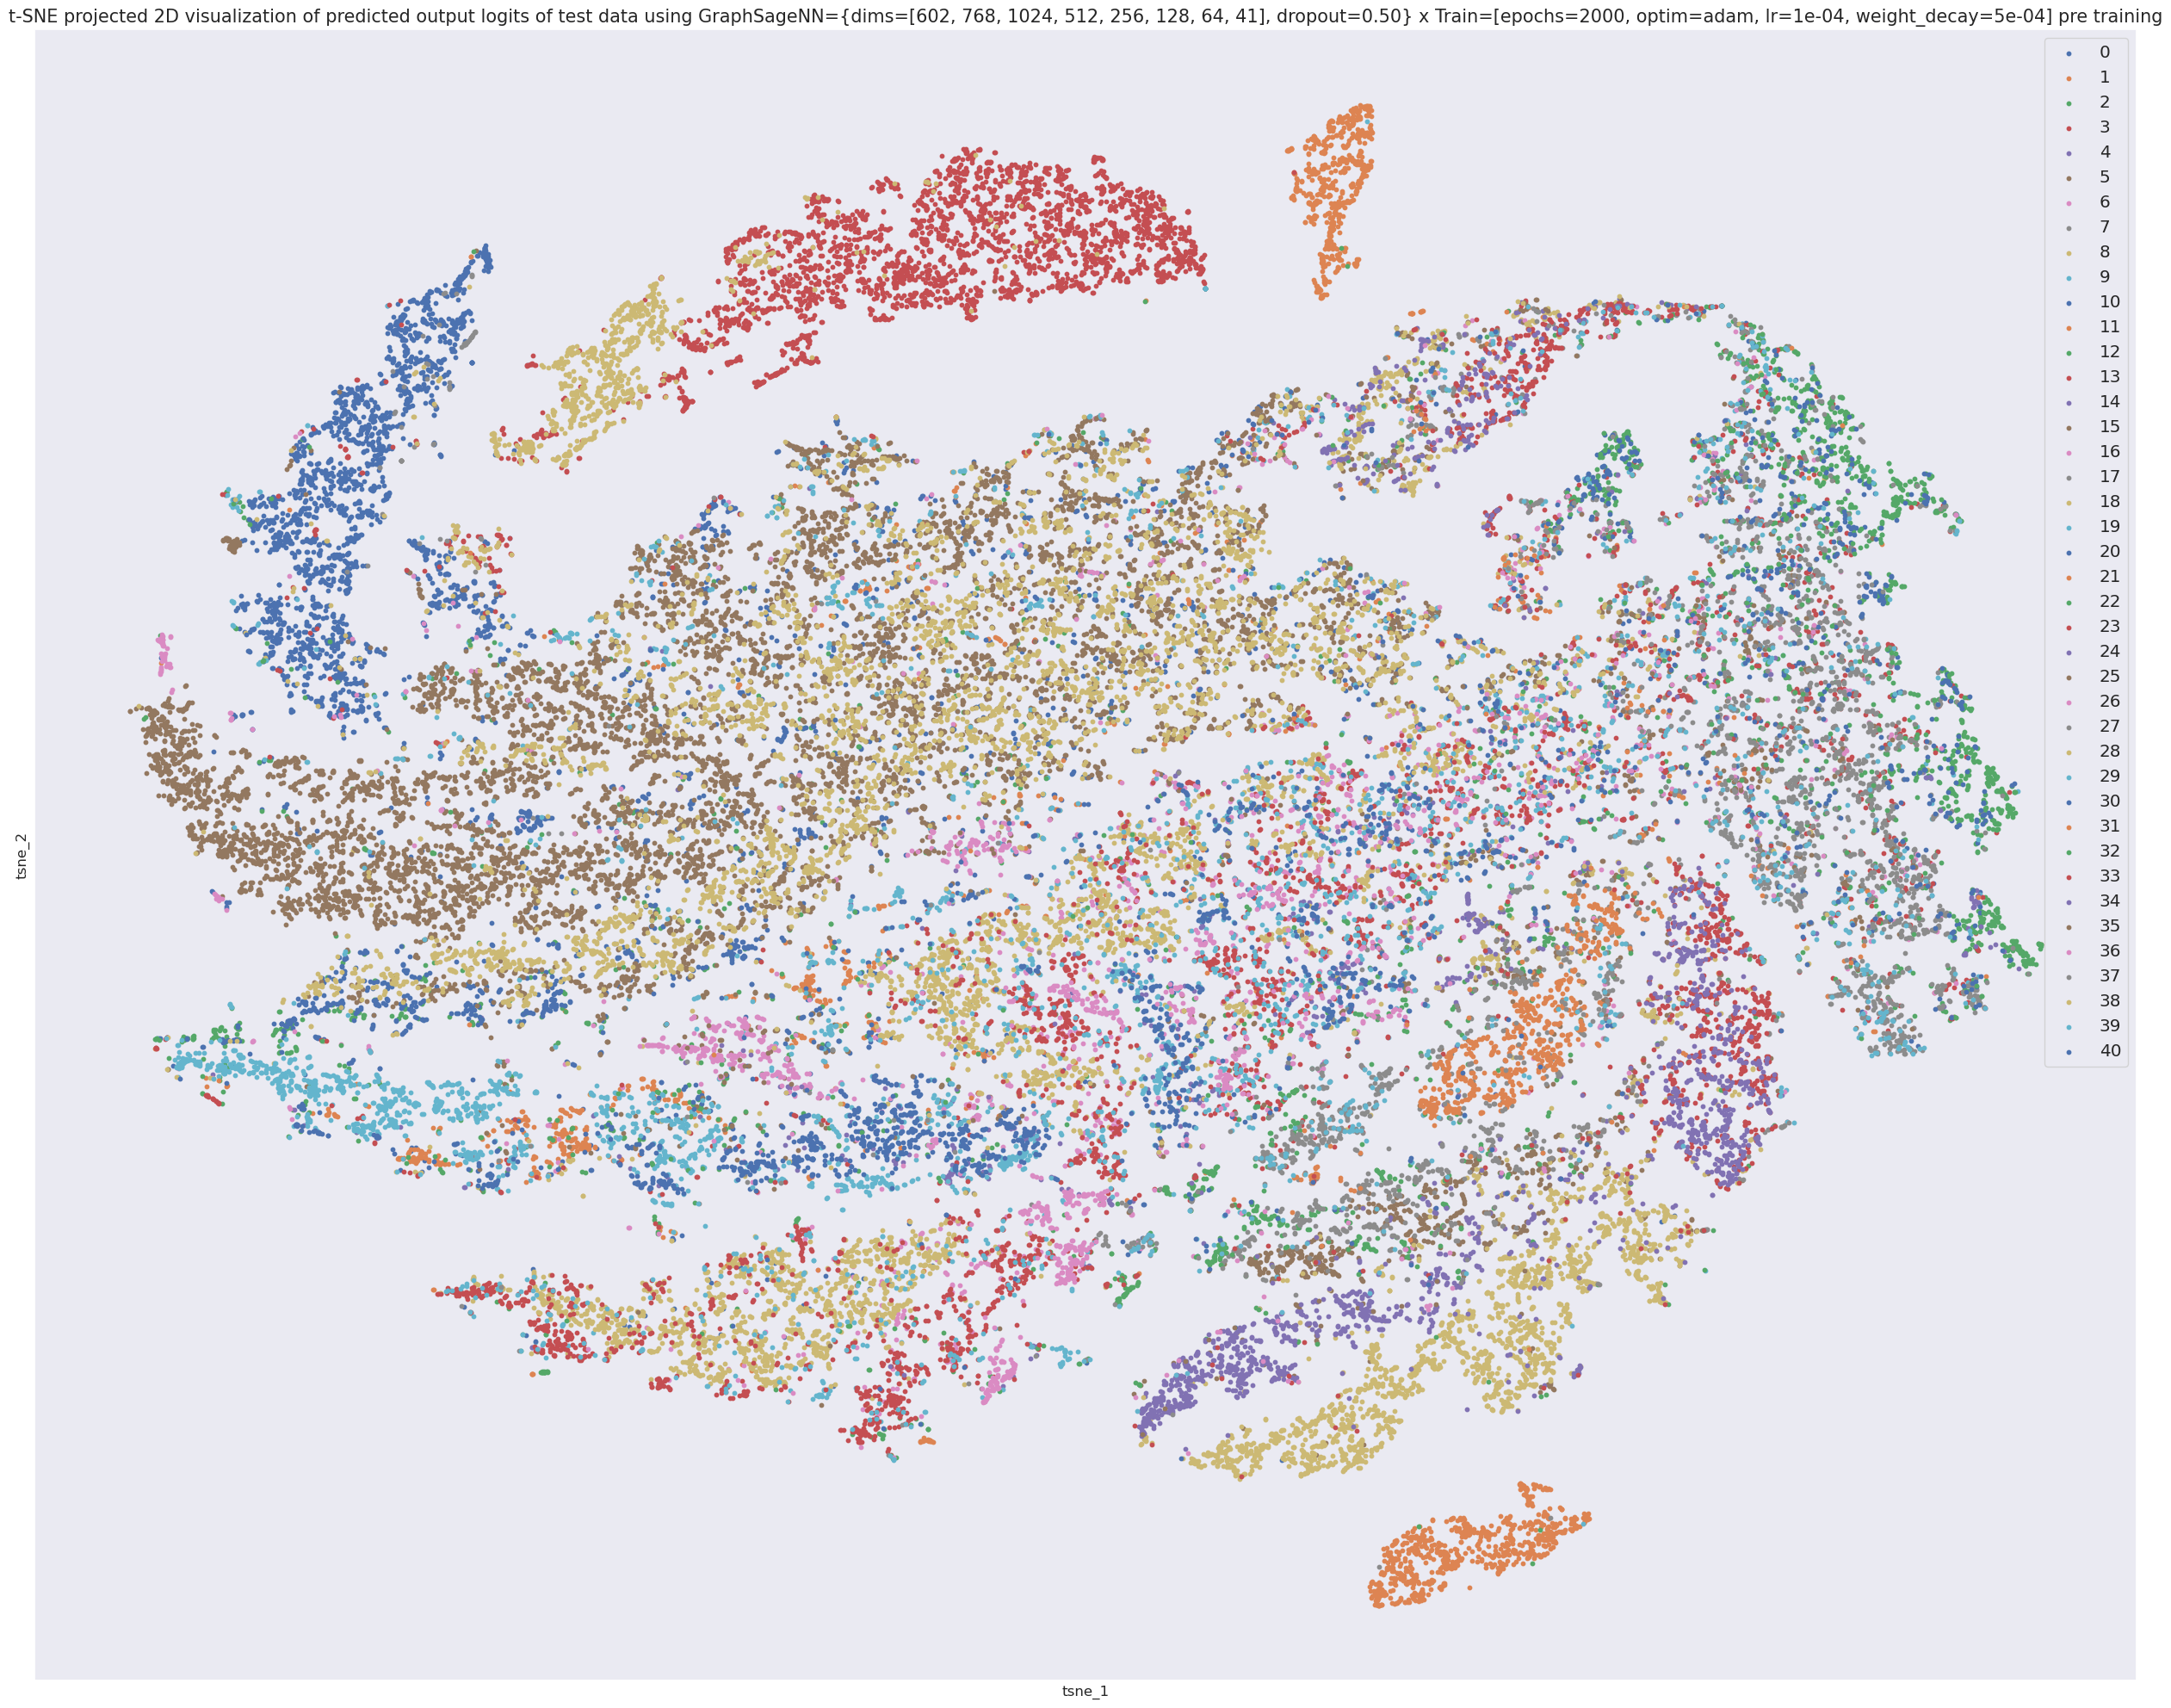

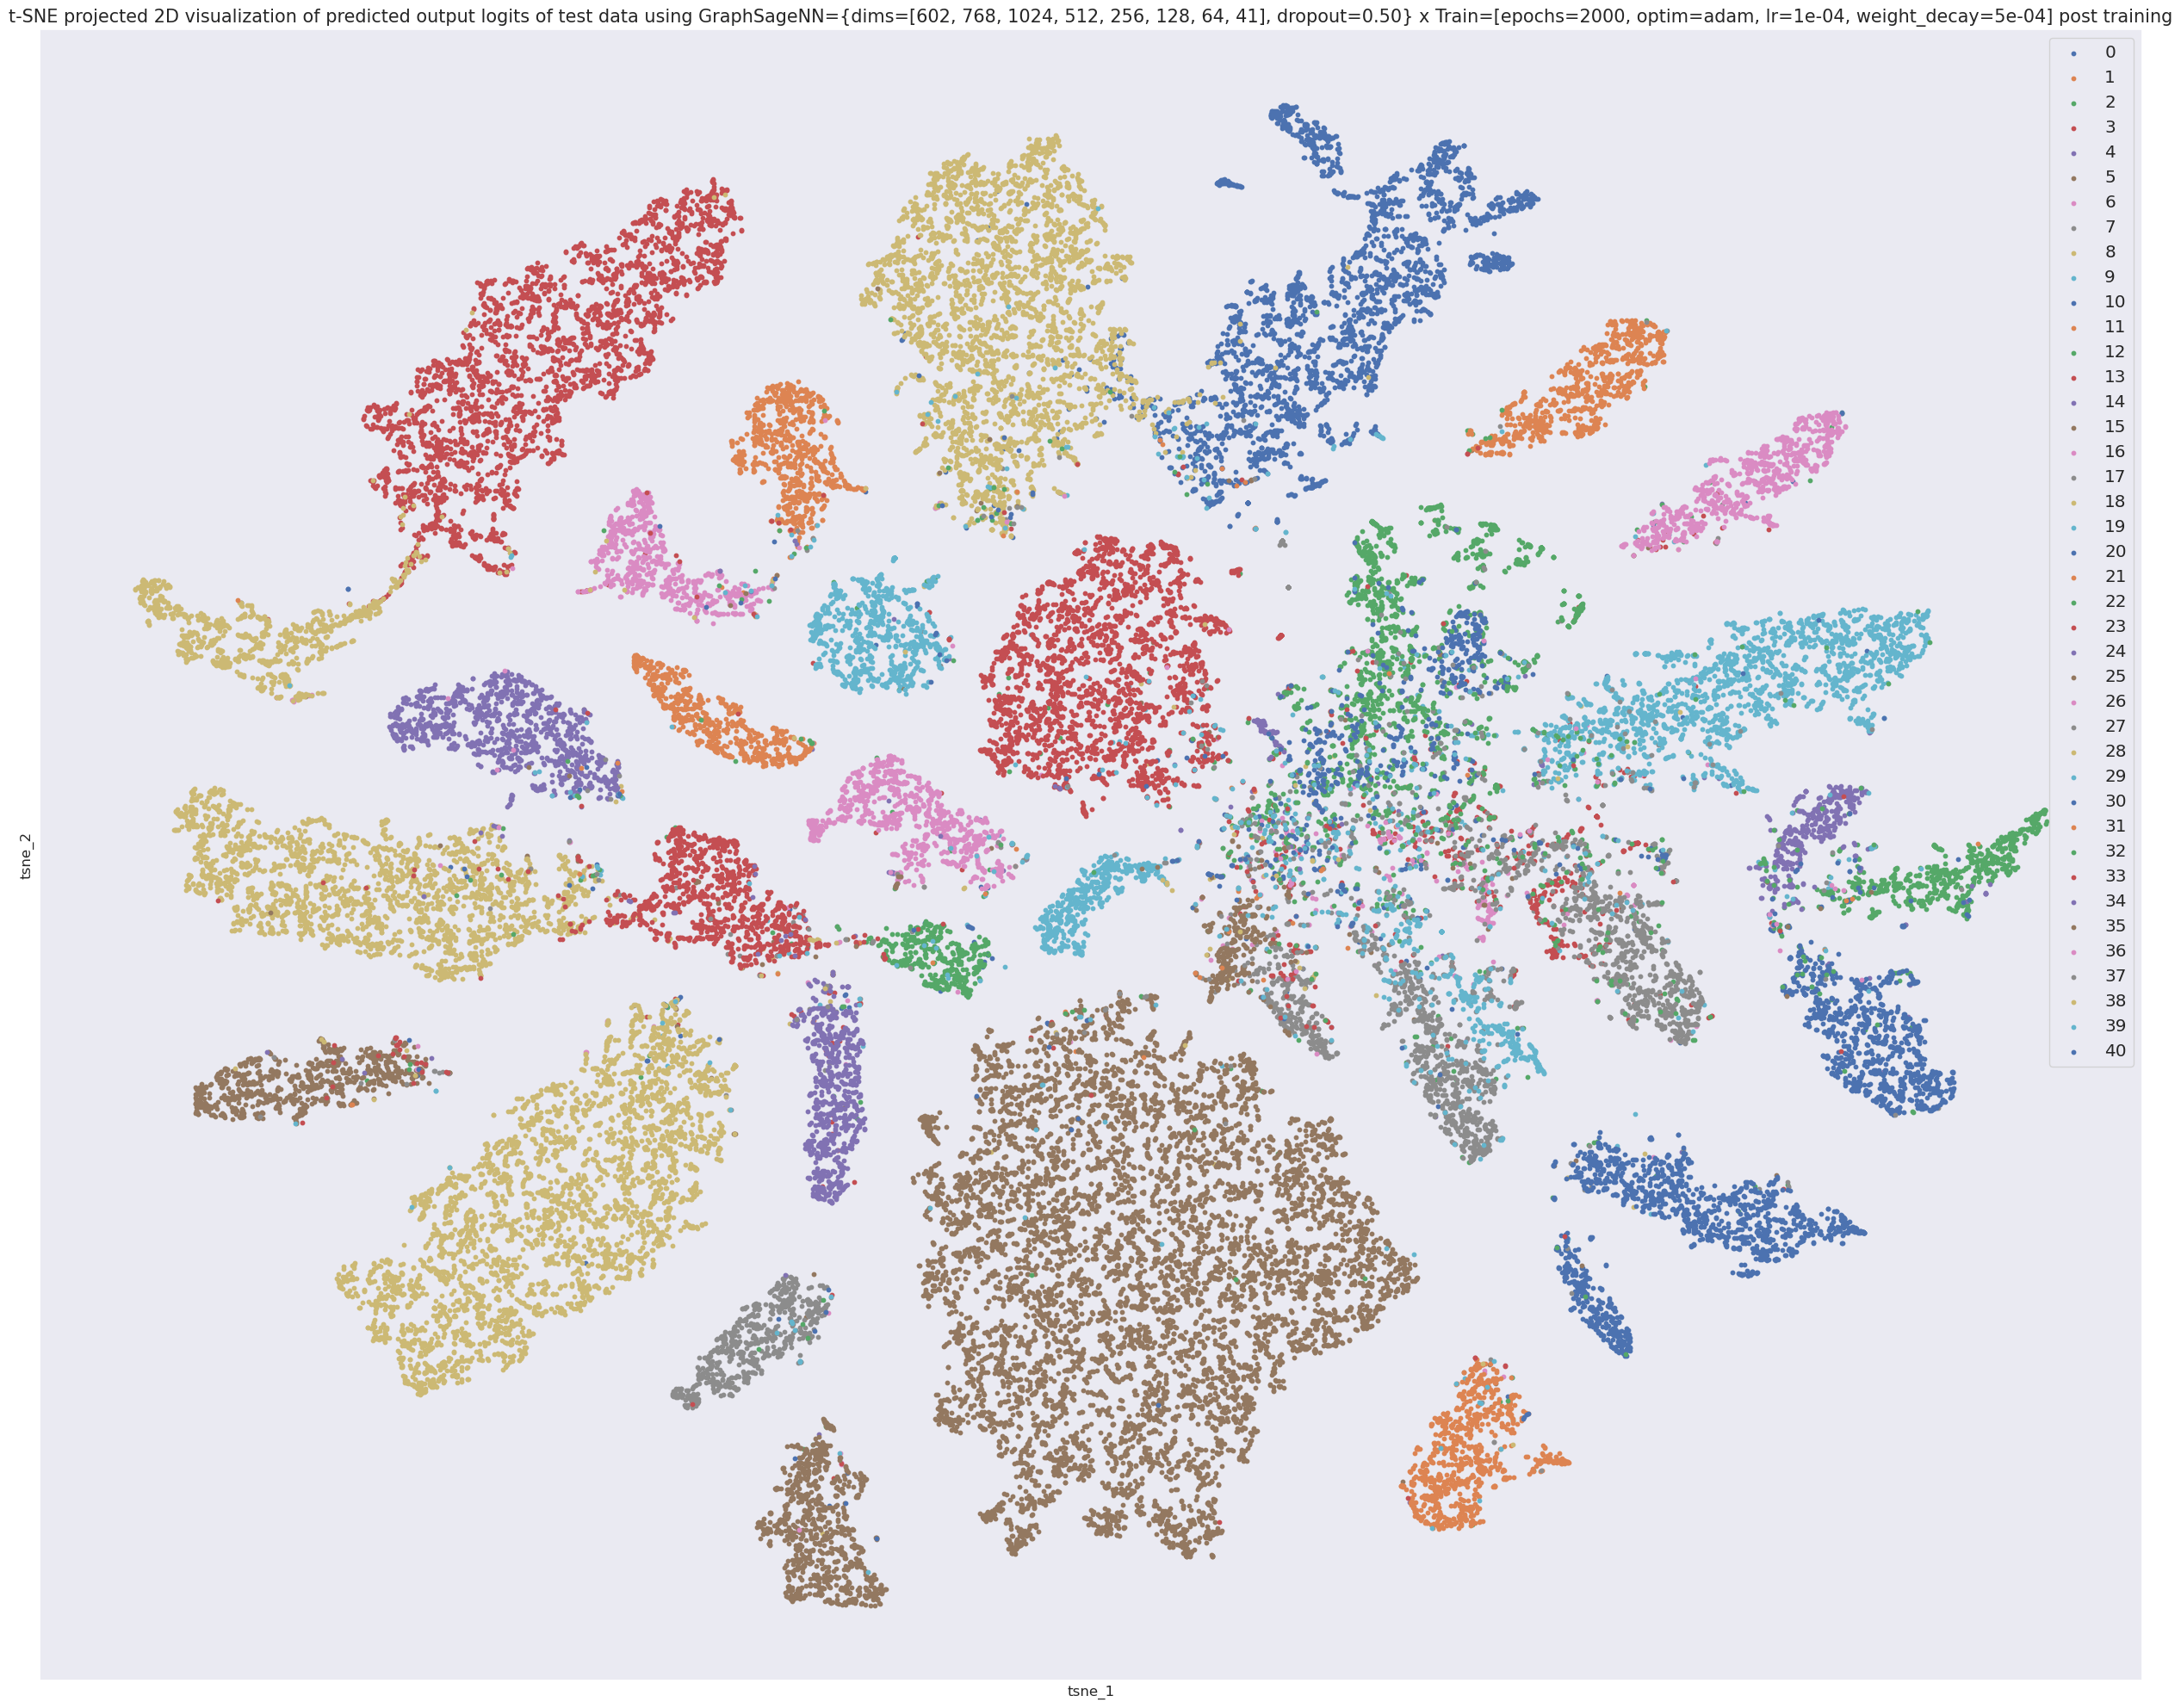

In [13]:
df_test_Y = pd.DataFrame(data=test_Y, columns=["community"])

test_Y_hat_post = model.predict(test_loader)

# Seed-node-only metrics via evaluate(loader) (applies GraphNNBase.seed_count);
# the previous manual unpack_batch scored seed + sampled-neighbor rows, leaking
# other-split labels and inflating the reported test accuracy.
test_edp = model.evaluate(test_loader)
print("Test data accuracy score post training: ", test_edp.accuracy)
print("Test data f1 score post training: ", test_edp.f1)
print("Test data recall score post training: ", test_edp.recall)
print("Test data precision score post training: ", test_edp.precision)

for at, test_Y_hat in [("pre", test_Y_hat_pre), ("post", test_Y_hat_post)]:
    VisUtils.scatter_plot(
        fig_size=DEFAULT_VAL_FIG_SIZE
        , title_size=DEFAULT_VAL_TITLE_SIZE
        , label_size=DEFAULT_VAL_LABEL_SIZE
        , vm=VisUtils.get_scatter_plot_vm(
            data=pd.concat(
                axis=1
                , objs=[
                    pd.DataFrame(
                        data=TSNE(
                            n_components=2
                        ).fit_transform(
                            X=pd.DataFrame(
                                data=test_Y_hat[0]
                            ).iloc[:N_SAMPLES, :]
                        )
                        , columns=["tsne_1", "tsne_2"]
                    )
                    , df_test_Y.iloc[:N_SAMPLES, :]
                ]
            )
            , uni_ts=ts
            , labels_ts=ts
            , colors_ts=cs
            , col_xs="tsne_1"
            , col_ys="tsne_2"
            , label_xs="tsne_1"
            , label_ys="tsne_2"
            , col_ts="community"
            , title=f"t-SNE projected 2D visualization of predicted output logits of test data using {model_str} {at} training"
        )
    )